<a href="https://colab.research.google.com/github/aabyyaann/midterm-machine-learning/blob/main/UTS_ML_NaufalAlifAbyan_101032300032.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# UTS Machine Learning - Naufal Alif Abyan (101032300032)
!pip install mlflow optuna lightgbm -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import optuna
import lightgbm as lgb
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Identitas User
NAMA = "Naufal Alif Abyan"
NIM = "101032300032"

print("Setup Library Berhasil.")

Setup Library Berhasil.


In [9]:
drive.mount('/content/drive', force_remount=True)

# Path berdasarkan gambar image_954ef6.png
PATH = "/content/drive/MyDrive/Midterm ML/"

print("Memuat data...")
train_df = pd.read_csv(PATH + 'train_transaction.csv', low_memory=False)
test_df = pd.read_csv(PATH + 'test_transaction.csv', low_memory=False)

# Optimasi memori agar tidak crash
def reduce_mem(df):
    for col in df.columns:
        if df[col].dtype == 'float64': df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
    return df

train_df = reduce_mem(train_df)
test_df = reduce_mem(test_df)
print(f"Data Train: {train_df.shape}, Data Test: {test_df.shape}")

Mounted at /content/drive
Memuat data...
Data Train: (590540, 394), Data Test: (506691, 393)


In [10]:
# Pilih 50 fitur pertama
features = [col for col in train_df.columns if col not in ['isFraud', 'TransactionID']]
features = features[:50]

X = train_df[features].copy()
y = train_df['isFraud']
X_test = test_df[features].copy()

# Robust Encoding untuk menangani label baru di data Test
for col in X.columns:
    if X[col].dtype == 'object':
        # Isi nilai kosong
        X[col] = X[col].fillna('Unknown')
        X_test[col] = X_test[col].fillna('Unknown')

        # Fit pada gabungan unik Train & Test agar tidak ada 'unseen labels'
        le = LabelEncoder()
        combined_values = pd.concat([X[col], X_test[col]], axis=0).astype(str)
        le.fit(combined_values)

        X[col] = le.transform(X[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
    else:
        # Isi numerik kosong dengan median
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Optuna Tuning
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'is_unbalance': True,
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 31, 100),
        'verbosity': -1
    }
    with mlflow.start_run(nested=True):
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)
print(f"Skor AUC Terbaik: {study.best_value}")

[I 2026-05-14 13:42:31,535] A new study created in memory with name: no-name-aa7b6c4f-ae51-4e98-82e5-8f8ca9ce0a35
[I 2026-05-14 13:42:56,602] Trial 0 finished with value: 0.9358287829005592 and parameters: {'learning_rate': 0.07413467934325746, 'num_leaves': 51}. Best is trial 0 with value: 0.9358287829005592.
[I 2026-05-14 13:43:15,814] Trial 1 finished with value: 0.93957043567874 and parameters: {'learning_rate': 0.08056548328889773, 'num_leaves': 59}. Best is trial 1 with value: 0.93957043567874.
[I 2026-05-14 13:43:37,248] Trial 2 finished with value: 0.9448951481468842 and parameters: {'learning_rate': 0.06254394760113571, 'num_leaves': 98}. Best is trial 2 with value: 0.9448951481468842.
[I 2026-05-14 13:43:56,673] Trial 3 finished with value: 0.9302489419179043 and parameters: {'learning_rate': 0.056355047005475965, 'num_leaves': 49}. Best is trial 2 with value: 0.9448951481468842.
[I 2026-05-14 13:44:19,808] Trial 4 finished with value: 0.950536786102071 and parameters: {'lear

Skor AUC Terbaik: 0.950536786102071


File prediksi berhasil disimpan di: /content/drive/MyDrive/Midterm ML/submission_fraud.csv


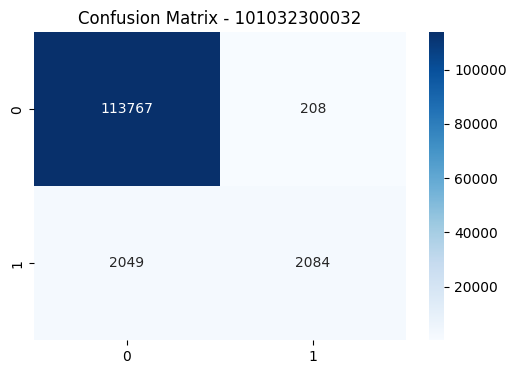

In [11]:
# Training model final
best_model = lgb.LGBMClassifier(**study.best_params)
best_model.fit(X_train, y_train)

# Prediksi untuk submission
test_preds = best_model.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({
    'TransactionID': test_df['TransactionID'],
    'isFraud': test_preds
})

# Simpan ke Drive sesuai instruksi UTS
submission.to_csv(PATH + 'submission_fraud.csv', index=False)
print(f"File prediksi berhasil disimpan di: {PATH}submission_fraud.csv")

# Visualisasi Confusion Matrix
val_preds = (best_model.predict_proba(X_val)[:, 1] > 0.5).astype(int)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, val_preds), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {NIM}')
plt.show()